In [2]:
import numpy as np
from sklearn.manifold import MDS
import matplotlib.pylab as pl
import pandas as pd

In [3]:
#HCP
subjects_HCP=['599469', '599671', '601127', '613538', '620434', '622236', '623844', '627549', '638049', '644044', '645551',
           '654754', '665254','672756','673455', '677968', '679568', '680957', '683256', '685058', '687163', '690152',
           '695768', '702133', '704238', '705341', '709551','715041','715647','729254', '729557', '732243', '734045', '742549',
           '748258', '748662', '749361', '751348', '753251', '756055', '759869', '761957','765056', '770352','771354', '779370',
           '782561', '784565', '786569', '789373', '792564', '792766', '802844', '814649', '816653', '826353','826454', '833148',
           '833249','837560', '837964', '845458', '849971', '856766', '857263', '859671', '861456', '865363', '871762', '871964',
           '872158', '872764', '877168', '877269','887373', '889579', '894673', '896778', '896879', '898176', '899885', '901038',
           '901139', '901442','904044', '907656', '910241', '912447', '917255','922854', '930449', '932554', '951457', '957974',
           '958976', '959574', '965367', '965771','978578', '979984', '983773', '984472', '987983', '991267','992774']

#PPMI/PD
subjects_PD=['100006','100007','100018','100267','100268','101026','101070','101146','101174','101279','101476','101479','101675',
             '101742','101751','101841','102053','102068a','102068b','102078','102305a','102305b','102321a','102321b','102978','106703',
             '107099','107648','109451','109619a','109619b','109910','110212','110220','111278','111383','111545a','111545b','112729',
             '113460','121109','121626','121830','126130','127075','127741','128196a','128196b','129515','33486a','133486b','133507a',
             '133507b','136600','136681a','136681b','137424a','137424b']
subjects_PD=['100267','100268']

#PPMI/Control
subjects_Control=['156484','180966','187823','212409','232204','241154','253417','293209a','293209b','293727','305710','311373','315233',
                  '335195']
subjects_Control=['156484']

#PPMI/Prodromal
subjects_Prodromal=['100122a','100122b','100122c','100250a','100250b','100971','101158a','101158b','101233a','101233b',
                    '101645a','101645b','101738','101761a','101761b','102073a','102073b','102119','102197a','102197b']
subjects_Prodromal=['100122a']

In [5]:
path="/home/gui/Documents/Post-doc/data/"

TRACT='CST_left'
alpha=0.0 #0.0 1e-05 5e-05 0.0001 0.0005 0.001 0.01 0.1 0.5 
nb_MAS=10

d1='HCP_105'
d2='PPMI_Control'
d3='PPMI_PD'
d4='PPMI_Prodromal'

list_d=[d1,d2,d3,d4]
list_subjects=[subjects_HCP,subjects_Control,subjects_PD,subjects_Prodromal]
list_lensum=[0,len(subjects_HCP),
                  len(subjects_HCP)+len(subjects_Control),
                  len(subjects_HCP)+len(subjects_Control)+len(subjects_PD),
                  len(subjects_HCP)+len(subjects_Control)+len(subjects_PD)+len(subjects_Prodromal)]


M=np.zeros((list_lensum[-1],list_lensum[-1]))

for i in range(3):
    for j in range(i,3):
        print(list_d[i],list_d[j])
        M_temp=pd.read_csv(path+'matrix_distance/'+list_d[i]+'_'+list_d[j]+'_'+TRACT+'_L'+str(nb_MAS)+'_alpha'+str(alpha)+'.csv',index_col=0)
        M_temp.index = M_temp.index.astype(str)
        M_temp.columns = M_temp.columns.astype(str)
        M[list_lensum[i]:list_lensum[i+1],list_lensum[j]:list_lensum[j+1]]= M_temp.loc[list_subjects[i],list_subjects[j]]

HCP_105 HCP_105
HCP_105 PPMI_Control
HCP_105 PPMI_PD
PPMI_Control PPMI_Control
PPMI_Control PPMI_PD
PPMI_PD PPMI_PD


In [10]:
M==0

array([[ True, False, False, ..., False, False,  True],
       [False,  True, False, ..., False, False,  True],
       [False, False,  True, ..., False, False,  True],
       ...,
       [ True,  True,  True, ...,  True, False,  True],
       [ True,  True,  True, ..., False,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(109, 109))

# Embedding in 2D

In [7]:
embedding = MDS(n_components=2, n_init=10,metric="precomputed",init="random")
X = embedding.fit_transform(M)

(np.float64(-19.627105284710613),
 np.float64(12.1944552773854),
 np.float64(-5.919062562368961),
 np.float64(6.077577719739408))

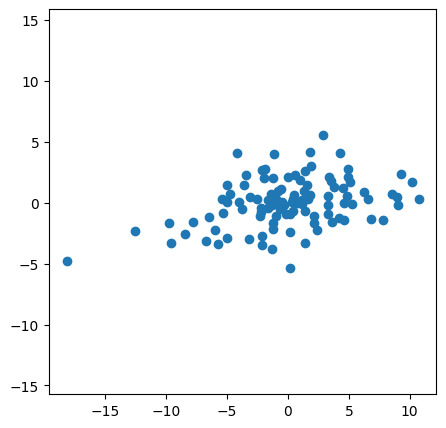

In [8]:
pl.figure(figsize=(5,5))
pl.scatter(X[:,0],X[:,1])
pl.axis("equal")

# Distribution of k-closest

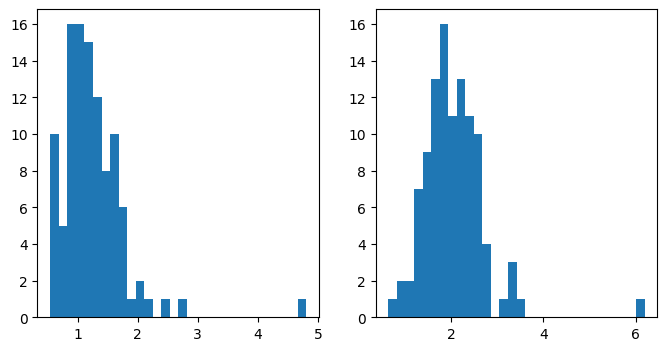

In [11]:
M_tilde=M+np.diag(M.max()*np.ones(M.shape[0]))
nearest=np.min(M_tilde,axis=0)

K=10
K_nearest=np.mean(np.sort(M_tilde,axis=1)[:,:K],1)

pl.figure(figsize=(8,4))
pl.subplot(1,2,1)
pl.hist(nearest,bins=30)

pl.subplot(1,2,2)
pl.hist(K_nearest,bins=30)
pl.show()